## 1. Import Libraries

In [1]:
!pip -q install kagglehub
import kagglehub, pandas as pd, numpy as np, glob, os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## 2. Download and Load the Real Kaggle Dataset

In [2]:
dataset_path=kagglehub.dataset_download("adrianjuliusaluoch/daily-google-search-trends-us")
csv_files=glob.glob(os.path.join(dataset_path,"**","*.csv"),recursive=True)
df=pd.read_csv(csv_files[0])
print("Dataset:",csv_files[0])
print("Shape:",df.shape)
print("Columns:",df.columns.tolist())
display(df.head())

100%|██████████| 935k/935k [00:00<00:00, 20.9MB/s]

Extracting files...


Dataset: /root/.cache/kagglehub/datasets/adrianjuliusaluoch/daily-google-search-trends-us/versions/194/trending_searches_in_us.csv
Shape: (31804, 8)
Columns: ['query', 'start_date', 'end_date', 'active', 'search_volume', 'increase_percentage', 'categories', 'trend_breakdown']


,query,start_date,end_date,active,search_volume,increase_percentage,categories,trend_breakdown
0,shedeur sanders,2026-03-30 18:40:00+00:00,NaN,True,200,50,Sports,NaN
1,whoopi goldberg,2026-03-30 18:40:00+00:00,NaN,True,5000,50,Politics,"america first award, mike johnson"
2,mo williams,2026-03-30 18:00:00+00:00,NaN,True,5000,300,Sports,"mason williams basketball, mason williams"
3,sloane stephens,2026-03-30 17:50:00+00:00,NaN,True,1000,200,"Sports, Health",NaN
4,canceled tv shows 2026,2026-03-30 17:50:00+00:00,NaN,True,5000,200,Entertainment,renewed and cancelled tv shows 2026


## 3. Prepare the Real Data

In [3]:
df.columns=(df.columns.str.strip().str.lower().str.replace(" ","_",regex=False))
query_candidates=[c for c in df.columns if any(w in c for w in ["query","search","trend","keyword","term"])]
if not query_candidates: raise ValueError("Search-query column not found.")
query_col=query_candidates[0]
df[query_col]=df[query_col].astype(str).str.strip().str.lower()
print("Search-query column:",query_col)
display(df[[query_col]].head())

Search-query column: query


,query
0,shedeur sanders
1,whoopi goldberg
2,mo williams
3,sloane stephens
4,canceled tv shows 2026


## 4. Create `Trend_Category`

In [4]:
def assign_category(q):
    q=str(q).lower()
    groups={
        "Technology":["ai","artificial intelligence","chatgpt","python","software","iphone","android","google","microsoft","tesla","technology","tech","robot"],
        "Sports":["football","soccer","nba","nfl","cricket","tennis","baseball","basketball","olympics","match","game","championship","player","team"],
        "Entertainment":["movie","film","actor","actress","music","song","concert","netflix","youtube","celebrity","tv","show","album"],
        "News":["news","president","election","government","war","politics","minister","court","law","protest"]
    }
    for cat,words in groups.items():
        if any(w in q for w in words): return cat
    return "General"

df["Trend_Category"]=df[query_col].apply(assign_category)
print("Derived target distribution:")
print(df["Trend_Category"].value_counts())
display(df[[query_col,"Trend_Category"]].head(10))

Derived target distribution:
Trend_Category
General          27477
Sports            1920
Technology        1171
News               776
Entertainment      460
Name: count, dtype: int64


,query,Trend_Category
0,shedeur sanders,General
1,whoopi goldberg,General
2,mo williams,General
3,sloane stephens,General
4,canceled tv shows 2026,Entertainment
5,atlas - guadalajara,General
6,karoline leavitt,General
7,kali uchis,General
8,germany vs ghana,General
9,caleb flynn,General


## 5. Create Numeric Features

In [5]:
numeric_cols=df.select_dtypes(include=np.number).columns.tolist()
df["query_length"]=df[query_col].str.len()
df["word_count"]=df[query_col].str.split().str.len()
feature_cols=list(dict.fromkeys(numeric_cols[:5]+["query_length","word_count"]))
X=df[feature_cols].copy()
y=df["Trend_Category"].copy()
print("Features:",feature_cols)
print("X shape:",X.shape," | y shape:",y.shape)

Features: ['search_volume', 'increase_percentage', 'query_length', 'word_count']
X shape: (31804, 4)  | y shape: (31804,)


## 6. CRISP-DM

1. Business Understanding – predict Google search trend category.  
2. Data Understanding – load and explore the dataset.  
3. Data Preparation – encode, impute and scale.  
4. Modeling – Random Forest.  
5. Evaluation – accuracy.  
6. Deployment – trained model is ready for prediction.



In [6]:
le=LabelEncoder()
y1=le.fit_transform(y)
imp=SimpleImputer(strategy="mean")
X1=imp.fit_transform(X)
sc=StandardScaler()
X1=sc.fit_transform(X1)
Xtr,Xte,ytr,yte=train_test_split(X1,y1,test_size=.2,random_state=42,stratify=y1)
model_crisp=RandomForestClassifier(n_estimators=100,random_state=42)
model_crisp.fit(Xtr,ytr)
pred=model_crisp.predict(Xte)
crisp_accuracy=accuracy_score(yte,pred)
print("CRISP-DM Accuracy:",round(crisp_accuracy,4))
print("CRISP-DM Accuracy (%):",round(crisp_accuracy*100,2))

CRISP-DM Accuracy: 0.8522
CRISP-DM Accuracy (%): 85.22


## 7. SEMMA

**Sample → Explore → Modify → Model → Assess**, matching the supplied Lab 1 procedure.

In [7]:
Xs=df[feature_cols].copy()
ys=df["Trend_Category"].copy()
Xtr,Xte,ytr,yte=train_test_split(Xs,ys,test_size=.2,random_state=42,stratify=ys)
les=LabelEncoder(); ytr=les.fit_transform(ytr); yte=les.transform(yte)
imps=SimpleImputer(strategy="mean"); Xtr=imps.fit_transform(Xtr); Xte=imps.transform(Xte)
scs=StandardScaler(); Xtr=scs.fit_transform(Xtr); Xte=scs.transform(Xte)
model_semma=RandomForestClassifier(n_estimators=100,random_state=42)
model_semma.fit(Xtr,ytr)
semma_accuracy=accuracy_score(yte,model_semma.predict(Xte))
print("SEMMA Accuracy:",round(semma_accuracy*100,2),"%")

SEMMA Accuracy: 85.24 %


## 8. KDD

**Selection → Preprocessing → Transformation → Data Mining → Interpretation/Evaluation**, matching the supplied Lab 1 procedure.

In [8]:
Xk=df[feature_cols].copy(); yk=df["Trend_Category"].copy()
lek=LabelEncoder(); yk=lek.fit_transform(yk)
impk=SimpleImputer(strategy="mean"); Xk=impk.fit_transform(Xk)
sck=StandardScaler(); Xk=sck.fit_transform(Xk)
Xtr,Xte,ytr,yte=train_test_split(Xk,yk,test_size=.2,random_state=42,stratify=yk)
model_kdd=RandomForestClassifier(n_estimators=100,random_state=42)
model_kdd.fit(Xtr,ytr)
kdd_accuracy=accuracy_score(yte,model_kdd.predict(Xte))
print("KDD Accuracy:",round(kdd_accuracy*100,2),"%")

KDD Accuracy: 85.22 %


## 9. Comparison

In [9]:
comparison=pd.DataFrame({
"Methodology":["CRISP-DM","SEMMA","KDD"],
"Accuracy (%)":[crisp_accuracy*100,semma_accuracy*100,kdd_accuracy*100],
"Main Focus":["Complete project lifecycle","Model building and assessment","Knowledge discovery"],
"Strength":["Comprehensive and industry standard","Strong analytics workflow","Good for research and preprocessing"],
"Limitation":["Requires more documentation","No deployment phase","No deployment phase"]})
comparison["Accuracy (%)"]=comparison["Accuracy (%)"].round(2)
display(comparison)

,Methodology,Accuracy (%),Main Focus,Strength,Limitation
0,CRISP-DM,85.22,Complete project lifecycle,Comprehensive and industry standard,Requires more documentation
1,SEMMA,85.24,Model building and assessment,Strong analytics workflow,No deployment phase
2,KDD,85.22,Knowledge discovery,Good for research and preprocessing,No deployment phase


## 10. Accuracy Visualization

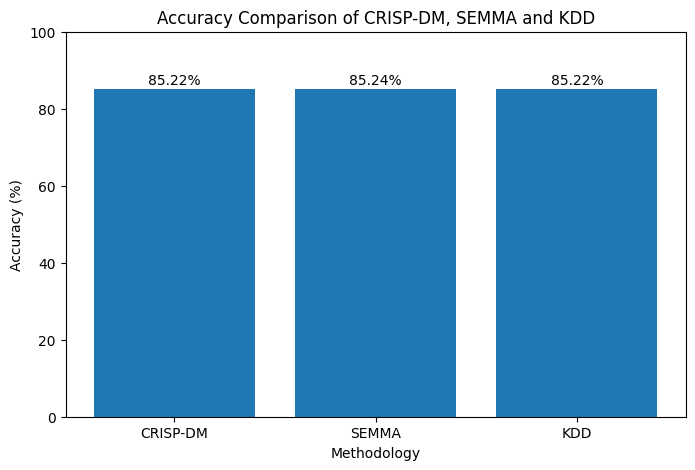

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(comparison["Methodology"],comparison["Accuracy (%)"])
plt.title("Accuracy Comparison of CRISP-DM, SEMMA and KDD")
plt.xlabel("Methodology"); plt.ylabel("Accuracy (%)"); plt.ylim(0,100)
for i,v in enumerate(comparison["Accuracy (%)"]): plt.text(i,v+1,f"{v:.2f}%",ha="center")
plt.show()